In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Configuration for Reproducibility
random_seed = 42
np.random.seed(random_seed)

# 2. Load CSV files
print("Loading CSV files...")
train_df = pd.read_csv('../data/fashion-mnist_train.csv')
test_df = pd.read_csv('../data/fashion-mnist_test.csv')

# Separate labels (y) and features (X)
y_train_all = train_df['label'].values
X_train_all_raw = train_df.drop('label', axis=1).values

y_test = test_df['label'].values
X_test_raw = test_df.drop('label', axis=1).values

# 3. Reconstruct 28x28 images BEFORE splitting
X_train_all_images = X_train_all_raw.reshape(-1, 28, 28).astype('uint8')
X_test_images = X_test_raw.reshape(-1, 28, 28).astype('uint8')

# 4. Define class names
class_names = np.array(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

# 5. Create Validation Split FIRST (Prevents Data Leakage)
# We split the raw pixels and the images at the same time so indices match
(X_train_raw, X_val_raw, 
 X_train_images, X_val_images, 
 y_train, y_val) = train_test_split(
    X_train_all_raw.astype('float32') / 255.0, # Normalize to [0,1]
    X_train_all_images, 
    y_train_all,
    test_size=10000,
    random_state=random_seed,
    stratify=y_train_all
)

# 6. Apply Standardization (Fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# Prepare Test Set
X_test_flat = X_test_raw.astype('float32') / 255.0
X_test_scaled = scaler.transform(X_test_flat)

Loading CSV files...


In [3]:
# 7. Export shared NPZ file for the whole team
np.savez_compressed('../data/fashion_data_complete.npz', 
                    X_train=X_train_scaled, 
                    X_val=X_val_scaled,
                    X_test=X_test_scaled,
                    y_train=y_train, 
                    y_val=y_val,
                    y_test=y_test,
                    X_train_images=X_train_images, # 50,000 synced images
                    X_val_images=X_val_images,     # 10,000 synced images
                    X_test_images=X_test_images,
                    class_names=class_names,
                    X_train_raw=X_train_raw,       # For Ablation Study
                    X_test_raw=X_test_flat)

print("Preprocessing Complete!")
print(f"Final Train Shape: {X_train_scaled.shape}")
print("Shared file 'fashion_data_complete.npz' has been generated.")

Preprocessing Complete!
Final Train Shape: (50000, 784)
Shared file 'fashion_data_complete.npz' has been generated.


 Data Export and Reproducibility
The final processed arrays were exported into a compressed **\texttt{.npz} archive**. This centralized file serves as the "Single Source of Truth" for the project:
*   **Shared Setting:** It guarantees that every team member trains and evaluates on the exact same pixel-level data.
*   **Pipeline Efficiency:** The archive includes standardized feature arrays for model training and raw flattened data for the upcoming Ablation Study, ensuring the entire pipeline is reproducible and consistent across different environments.

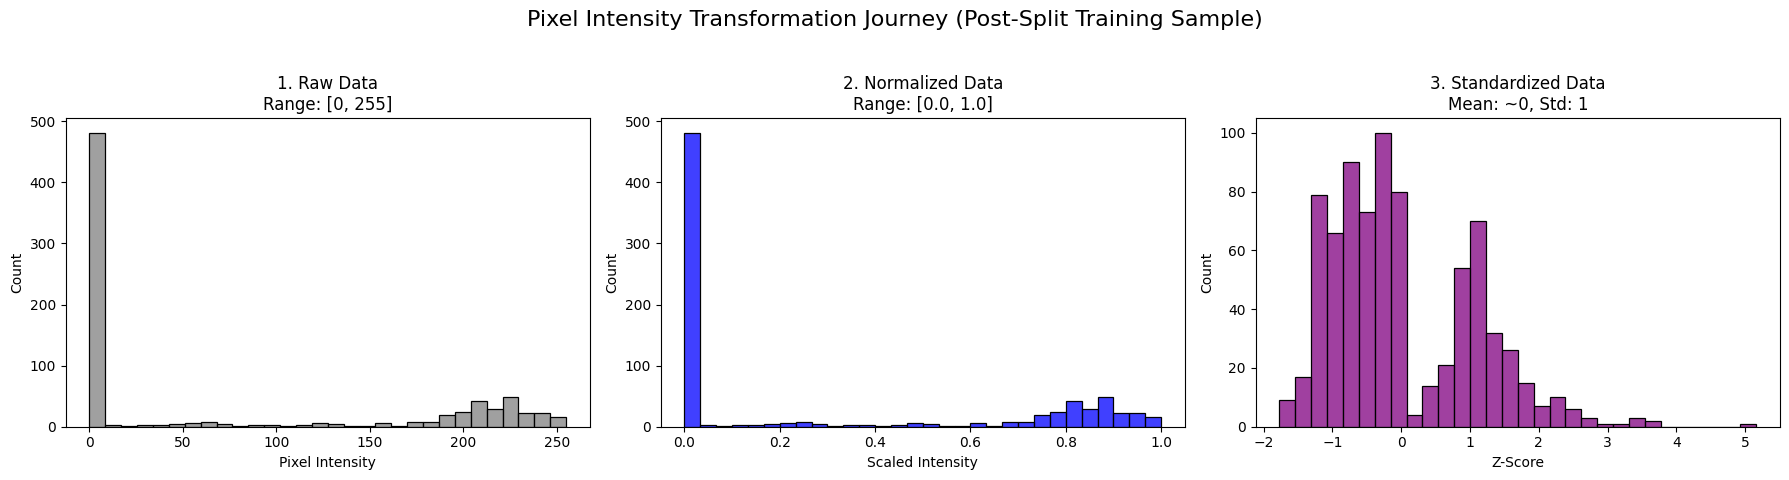

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a sample from the split training set
sample_idx = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Raw Data (from the original DF for true raw context)
sns.histplot(X_train_raw[sample_idx] *255, bins=30, ax=axes[0], color='gray')
axes[0].set_title(f"1. Raw Data\nRange: [0, 255]")
axes[0].set_xlabel("Pixel Intensity")

# Plot 2: Normalized Data (0-1)
sns.histplot(X_train_raw[sample_idx], bins=30, ax=axes[1], color='blue')
axes[1].set_title(f"2. Normalized Data\nRange: [{X_train_raw.min():.1f}, {X_train_raw.max():.1f}]")
axes[1].set_xlabel("Scaled Intensity")

# Plot 3: Standardized Data (Mean=0, Std=1)
sns.histplot(X_train_scaled[sample_idx], bins=30, ax=axes[2], color='purple')
axes[2].set_title(f"3. Standardized Data\nMean: ~0, Std: 1")
axes[2].set_xlabel("Z-Score")

plt.suptitle("Pixel Intensity Transformation Journey (Post-Split Training Sample)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 1. From Raw to Normalized: Reducing Magnitude
*   **Observation:** The shape of the histogram in Panel 1 (Raw) and Panel 2 (Normalized) is exactly the same, but the X-axis scale has changed from $[0, 255]$ to $[0, 1]$.
*   **The Insight:** This is a **linear scaling**. It prevents "numerical explosion." 
*   **Model Benefit:** For your **MLP (Neural Network)**, this is vital. Neural networks use weight multiplication. If the inputs are as large as $255$, the weights can quickly grow too large, causing the model to become unstable. Scaling to $[0, 1]$ keeps the math "quiet" and controllable.

### 2. The Bimodal Nature: Background vs. Foreground
*   **Observation:** In all three charts, you see two distinct "humps" or peaks. 
*   **The Insight:** 
    *   **The Left Peak:** Represents the black background pixels (value $0$ or near $0$). Notice how it is the tallest peak because most of a $28 \times 28$ image is empty space.
    *   **The Right Peak:** Represents the actual clothing item (higher intensity pixels). 
*   **The Insight:** Preprocessing preserves this "object vs. background" distinction while making it mathematically easier to process.

### 3. From Normalized to Standardized: Centering the "Vote"
*   **Observation:** In Panel 3, the data is now centered around **0**. You have negative values ($\approx -1$) and positive values (up to $\approx 6$).
*   **The Insight:** This is the most important step for your **KNN and SVM**. 
    *   **Fairness:** Without this, pixels with very high intensity would dominate the "distance" calculation in KNN. Standardization ensures that every pixel (feature) has an equal chance to influence the model.
    *   **Zero-Centering:** For your **MLP**, having a mean of zero helps the optimizer (like Adam or SGD) find the "downhill" path to the best accuracy much faster.

### 4. Handling Outliers (The Long Tail)
*   **Observation:** In the Standardized plot, notice the "tail" that goes all the way out to **$6$**.
*   **The Insight:** Most pixels sit between $-1$ and $+2$. Pixels at $+6$ are "extreme" intensities compared to the average. Standardization highlights these important features (like the bright white parts of a sneaker or a t-shirt) so the model can pay more attention to them.



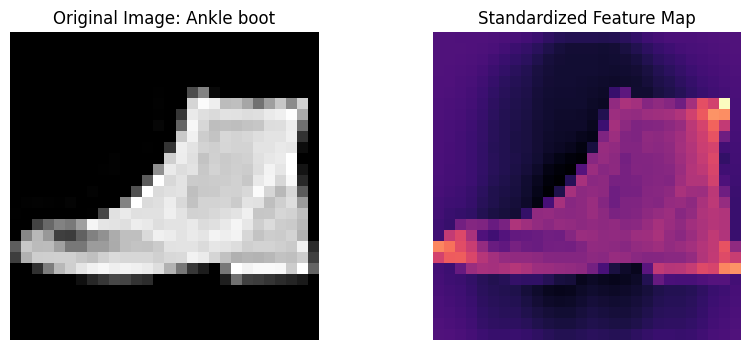

In [5]:
# Visualizing the effect on the image (Now using Synchronized Split Images)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# Using the split images to ensure this matches X_train_scaled[0]
plt.imshow(X_train_images[sample_idx], cmap='gray') 
plt.title(f"Original Image: {class_names[y_train[sample_idx]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
std_image_view = X_train_scaled[sample_idx].reshape(28,28)
plt.imshow(std_image_view, cmap='magma')
plt.title("Standardized Feature Map")
plt.axis('off')
plt.show()

### Qualitative Analysis of Feature Standardization

The visual transition from raw 8-bit images to standardized feature maps justifies the preprocessing pipeline by shifting data from a human-readable format to a mathematically optimized representation.

#### 1. Comparison: Raw vs. Standardized
*   **Original 8-Bit Image:** Raw intensities ($0–255$) focus on brightness. In this state, large numerical magnitudes can disproportionately bias distance-based metrics (k-NN) and gradient updates (MLP), causing algorithms to prioritize "brightness" over actual structural features.
*   **Standardized Feature Map:** Applying Z-score standardization ($z = (x - \mu) / \sigma$) centers the data at a mean of $0$. Using a "Magma" colormap, the map highlights **feature salience**: bright orange/yellow regions indicate high-variance structural details (edges, textures, and silhouettes), while the background is suppressed into a consistent negative baseline.

#### 2. Model-Specific Implications
*   **k-NN and SVM:** Standardization ensures that distance metrics (Euclidean/Manhattan) and kernel functions (RBF) are calculated based on statistical significance rather than raw magnitude. This prevents high-intensity pixels from dominating the classification "vote."
*   **MLP:** Zero-centered inputs prevent activation function saturation during backpropagation, resulting in more stable gradients, faster convergence, and higher final accuracy.
*   **Random Forest:** While naturally scale-invariant, providing a standardized map maintains a **shared experimental setting**, ensuring a fair and consistent comparison across all four model families.

--- Class Distribution Table ---
      Class  Train Count  Val Count  Test Count  Total
T-shirt/top         5000       1000        1000   7000
    Trouser         5000       1000        1000   7000
   Pullover         5000       1000        1000   7000
      Dress         5000       1000        1000   7000
       Coat         5000       1000        1000   7000
     Sandal         5000       1000        1000   7000
      Shirt         5000       1000        1000   7000
    Sneaker         5000       1000        1000   7000
        Bag         5000       1000        1000   7000
 Ankle boot         5000       1000        1000   7000


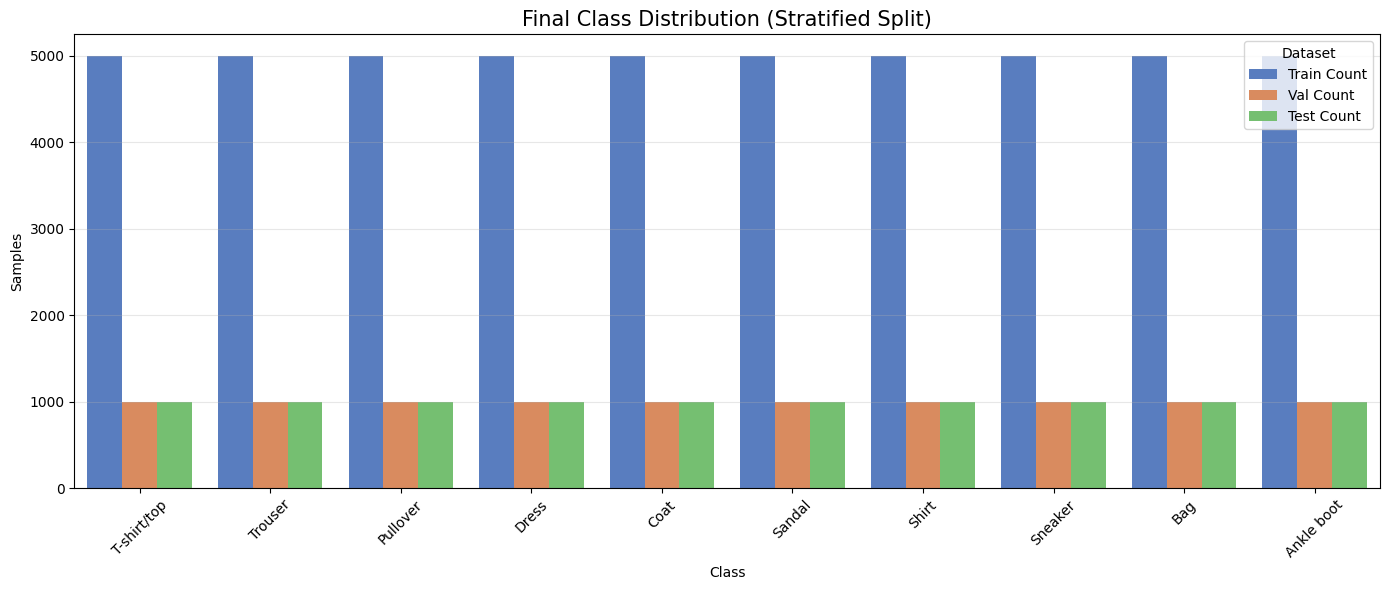

In [6]:
# Verify class distribution in the finalized split
# 1. Load the exported data to verify what the team will see
data = np.load('../data/fashion_data_complete.npz')
y_train_final = data['y_train']
y_val_final = data['y_val']
y_test_final = data['y_test']
class_names = data['class_names']

def get_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    return pd.DataFrame({'Class': class_names, f'{name} Count': counts})

dist_train = get_distribution(y_train_final, 'Train')
dist_val = get_distribution(y_val_final, 'Val')
dist_test = get_distribution(y_test_final, 'Test')

df_dist = dist_train.merge(dist_val, on='Class').merge(dist_test, on='Class')
df_dist['Total'] = df_dist['Train Count'] + df_dist['Val Count'] + df_dist['Test Count']

print("--- Class Distribution Table ---")
print(df_dist.to_string(index=False))

df_plot = df_dist.melt(id_vars='Class', value_vars=['Train Count', 'Val Count', 'Test Count'], 
                       var_name='Dataset', value_name='Samples')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x='Class', y='Samples', hue='Dataset', palette='muted')
plt.title('Final Class Distribution (Stratified Split)', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Data Partitioning and Distribution

The processed dataset was partitioned into three subsets: **Training (50,000)**, **Validation (10,000)**, and **Test (10,000)**. We employed a **stratified split strategy** to ensure the original class proportions were maintained across all partitions.

####  Distribution Analysis
As illustrated in the "Class Distribution" chart, the stratification process was successful:
*   Each of the 10 clothing categories contains exactly **5,000 training samples** and **1,000 samples** for both validation and testing.
*   **Insight:** This perfect class balance is critical for preventing model bias. It ensures that algorithms like **SVM** and **MLP** do not favor majority classes, making the final accuracy and F1-score reliable metrics for comparison.

